In [1]:
from tqdm import tqdm
from multiprocess import Pool
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from mass_flux_gamma import *
from linear_flux import *
from distribution_breadth import *
import cmcrameri.cm as cmc
import os

In [2]:
params={     
    'axes.labelsize'  : '14',   
    'axes.titlesize'  : '14',  
    'xtick.labelsize' :'14',
    'ytick.labelsize' :'14',    
    'lines.linewidth' : '2' ,   
    'legend.fontsize' : '12', 
    'figure.figsize'   : '12, 7'    
}
plt.rcParams.update(params)

In [3]:

def scatter_to_contour(x_in,y_in,z_in):
    # 1D scattered data
    x = np.asarray(x_in)
    y = np.asarray(y_in)
    z = np.asarray(z_in)

    # make regular grid
    xi = np.linspace(0, 20, 100)
    yi = np.linspace(-20, 1, 100)
    Xi, Yi = np.meshgrid(xi, yi)

    # interpolate scattered data onto grid
    Zi = griddata((x, y), z, (Xi, Yi), method="linear")
    return Xi, Yi, Zi

In [4]:
def get_Palmer_plane_skew(z_b=1400,mprofile="cos",skew_type = "left", read_from_file=False):
    
    fname = f"Data/LCL_ext_{z_b}m_mprof-{mprofile}_skew-{skew_type}.csv"

    if os.path.exists(fname) & read_from_file:
       df = pd.read_csv(fname)
       return df

    # 1. Create (RH, P) pairs

    ## Use sequences
    #RH_values = np.linspace(0.01, 0.99, 50)
    #P_values = np.linspace(0, 20, 30)

    RH_values = np.linspace(0.02, 0.99, 25)
    P_values = np.linspace(0, 30, 31)# np.linspace(0, 50, 51)# 


    param_pairs = [(RH, P) for RH in RH_values for P in P_values]

    # 2. Define worker function
    def worker(args):
        RH, P = args
        CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def,dz,ent_b, ent_std = spectral_plume_skew(
            model_type="precip", RH=RH, P=P, z_lcl=z_b,mprofile=mprofile,
            get_plane=True, plotting=False, save_data=False,skew_type = skew_type
        )
        return CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def, P, RH,dz,ent_b, ent_std

    # 3. Run in parallel
    num_cpus = 4
    with Pool(processes=num_cpus) as pool:
        results = list(tqdm(pool.imap(worker, param_pairs), total=len(param_pairs)))


    # 4. Unpack results
    CAPEu_list, CAPEext_list, CAPEdist_list, dh_list, sat_def_list, P_list,RH_list,dz_list,ent_b_list, ent_std_list = zip(*results)
    CAPEu_list = list(CAPEu_list)
    CAPEext_list = list(CAPEext_list)
    CAPEdist_list = list(CAPEdist_list)
    dh_list = list(dh_list)
    sat_def_list = list(sat_def_list)
    P_list = list(P_list)
    RH_list = list(RH_list)
    dz_list = list(dz_list)
    ent_b_list = list(ent_b_list)
    ent_std_list = list(ent_std_list)

    # 5. Save to CSV
    df = pd.DataFrame({
        "CAPE_u":CAPEu_list,
        "CAPE_ext": CAPEext_list,
        "CAPE_dist": CAPEdist_list,
        "dh": dh_list,
        "sat_def": sat_def_list,
        "P": P_list,
        "RH": RH_list,
        "dz": dz_list,
        "ent_b":ent_b_list,
        "ent_std": ent_std_list
                })
    df.to_csv(fname, index=False)

    return df

def get_Palmer_plane_linear(z_b=1400,mprofile="cos",skew_type = "linear-increase", read_from_file=False):
    
    fname = f"Data/LCL_ext_{z_b}m_mprof-{mprofile}_{skew_type}.csv"

    if os.path.exists(fname) & read_from_file:
       df = pd.read_csv(fname)
       return df

    # 1. Create (RH, P) pairs

    ## Use sequences
    #RH_values = np.linspace(0.01, 0.99, 50)
    #P_values = np.linspace(0, 20, 30)

    RH_values = np.linspace(0.02, 0.98, 25)
    P_values = np.linspace(0, 30, 31)


    param_pairs = [(RH, P) for RH in RH_values for P in P_values]

    # 2. Define worker function
    def worker(args):
        RH, P = args
        CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def,dz,ent_b,ent_spec, a, b = spectral_plume_linear(
            model_type="precip", RH=RH, P=P, z_lcl=z_b,mprofile=mprofile,
            get_plane=True, plotting=False, save_data=False,skew_type = skew_type
        )
        return CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def, P, RH,dz,ent_b,ent_spec, a, b

    # 3. Run in parallel
    num_cpus = 4
    with Pool(processes=num_cpus) as pool:
        results = list(tqdm(pool.imap(worker, param_pairs), total=len(param_pairs)))


    # 4. Unpack results
    CAPEu_list, CAPEext_list, CAPEdist_list, dh_list, sat_def_list, P_list,RH_list,dz_list,ent_b_list,ent_spec_list, a_list, b_list = zip(*results)
    CAPEu_list = list(CAPEu_list)
    CAPEext_list = list(CAPEext_list)
    CAPEdist_list = list(CAPEdist_list)
    dh_list = list(dh_list)
    sat_def_list = list(sat_def_list)
    P_list = list(P_list)
    RH_list = list(RH_list)
    dz_list = list(dz_list)
    ent_b_list = list(ent_b_list)
    ent_spec_list = list(ent_spec_list)
    a_list = list(a_list)
    b_list = list(b_list)

    # 5. Save to CSV
    df = pd.DataFrame({
        "CAPE_u":CAPEu_list,
        "CAPE_ext": CAPEext_list,
        "CAPE_dist": CAPEdist_list,
        "dh": dh_list,
        "sat_def": sat_def_list,
        "P": P_list,
        "RH": RH_list,
        "dz": dz_list,
        "ent_b":ent_b_list,
        "ent_spec":ent_spec_list,
        "a":a_list,
        "b":b_list
                })
    df.to_csv(fname, index=False)

    return df

def get_Palmer_plane_breadth(z_b=1400,mprofile="cos",skew_type = "left", read_from_file=False):
    
    fname = f"Data/LCL_ext_{z_b}m_mprof-{mprofile}_skew-{skew_type}.csv"

    if os.path.exists(fname) & read_from_file:
       df = pd.read_csv(fname)
       return df

    # 1. Create (RH, P) pairs

    ## Use sequences
    #RH_values = np.linspace(0.01, 0.99, 50)
    #P_values = np.linspace(0, 20, 30)

    RH_values = np.linspace(0.02, 0.99, 25)
    P_values = np.linspace(0, 30, 31)# np.linspace(0, 50, 51)# 


    param_pairs = [(RH, P) for RH in RH_values for P in P_values]

    # 2. Define worker function
    def worker(args):
        RH, P = args
        CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def,dz,ent_b, ent_std = spectral_plume_breadth(
            model_type="precip", RH=RH, P=P, z_lcl=z_b,mprofile=mprofile,
            get_plane=True, plotting=False, save_data=False,skew_type = skew_type
        )
        return CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def, P, RH,dz,ent_b, ent_std

    # 3. Run in parallel
    num_cpus = 4
    with Pool(processes=num_cpus) as pool:
        results = list(tqdm(pool.imap(worker, param_pairs), total=len(param_pairs)))


    # 4. Unpack results
    CAPEu_list, CAPEext_list, CAPEdist_list, dh_list, sat_def_list, P_list,RH_list,dz_list,ent_b_list, ent_std_list = zip(*results)
    CAPEu_list = list(CAPEu_list)
    CAPEext_list = list(CAPEext_list)
    CAPEdist_list = list(CAPEdist_list)
    dh_list = list(dh_list)
    sat_def_list = list(sat_def_list)
    P_list = list(P_list)
    RH_list = list(RH_list)
    dz_list = list(dz_list)
    ent_b_list = list(ent_b_list)
    ent_std_list = list(ent_std_list)

    # 5. Save to CSV
    df = pd.DataFrame({
        "CAPE_u":CAPEu_list,
        "CAPE_ext": CAPEext_list,
        "CAPE_dist": CAPEdist_list,
        "dh": dh_list,
        "sat_def": sat_def_list,
        "P": P_list,
        "RH": RH_list,
        "dz": dz_list,
        "ent_b":ent_b_list,
        "ent_std": ent_std_list
                })
    df.to_csv(fname, index=False)

    return df

In [36]:
%%time

# Set the model parameters

z_b = 700
mprofile = "cos"

df_normal = get_Palmer_plane_breadth(z_b,mprofile,skew_type = "normal", read_from_file=True)
df_left = get_Palmer_plane_breadth(z_b,mprofile,skew_type = "left", read_from_file=True)
df_right = get_Palmer_plane_breadth(z_b,mprofile=mprofile,skew_type = "right", read_from_file=True)

df_normal_narrow = get_Palmer_plane_breadth(z_b,mprofile,skew_type = "normal_narrow", read_from_file=True)
df_left_narrow = get_Palmer_plane_breadth(z_b,mprofile,skew_type = "left_narrow", read_from_file=True)
df_right_narrow = get_Palmer_plane_breadth(z_b,mprofile=mprofile,skew_type = "right_narrow", read_from_file=True)
df_normal_wide = get_Palmer_plane_breadth(z_b,mprofile,skew_type = "normal_wide", read_from_file=True)
df_left_wide = get_Palmer_plane_breadth(z_b,mprofile,skew_type = "left_wide", read_from_file=True)
df_right_wide = get_Palmer_plane_breadth(z_b,mprofile=mprofile,skew_type = "right_wide", read_from_file=True)
# df_right_h = get_Palmer_plane_skew(z_b=1400,mprofile=mprofile,skew_type = "right", read_from_file=True)


  0%|          | 0/775 [00:00<?, ?it/s]

 70%|██████▉   | 540/775 [01:17<00:33,  6.96it/s]

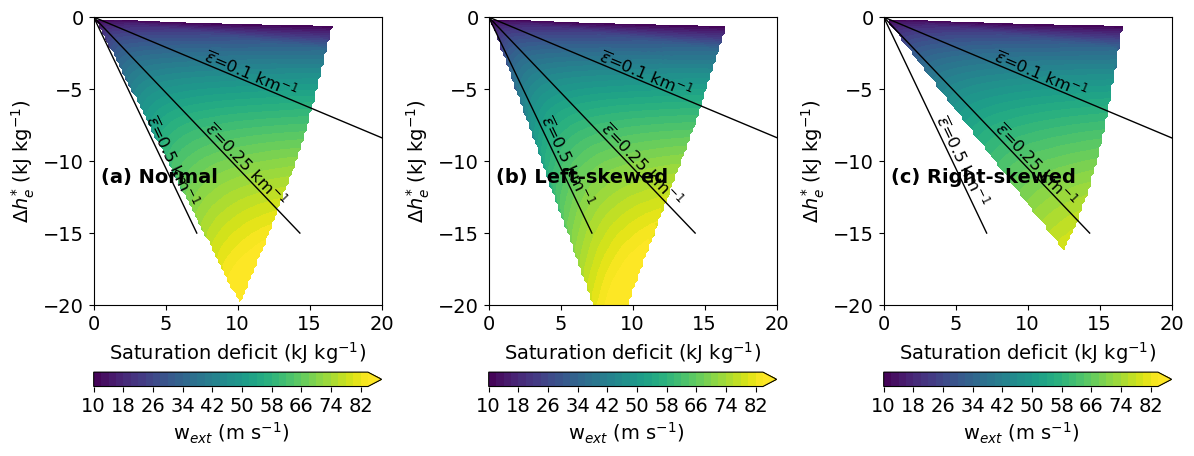

In [6]:

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_normal["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_normal["dh"])/1000
CAPEdist_list = np.array(df_normal["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_normal["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_normal["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(a) Normal",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(132)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_left["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_left["dh"])/1000
CAPEdist_list = np.array(df_left["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_left["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_left["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(b) Left-skewed",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(133)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_right["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_right["dh"])/1000
CAPEdist_list = np.array(df_right["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_right["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_right["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(c) Right-skewed",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')
plt.tight_layout()

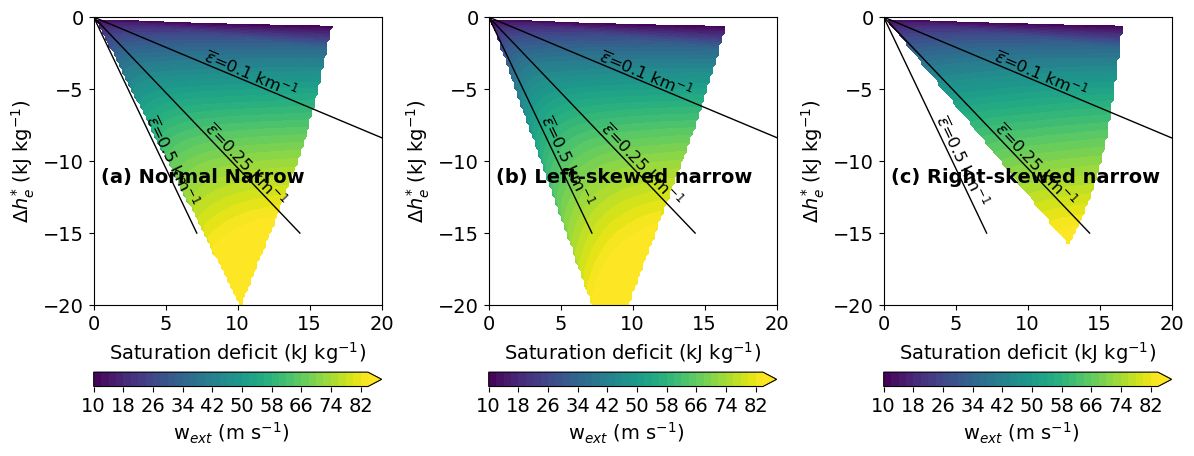

In [7]:

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_normal_narrow["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_normal_narrow["dh"])/1000
CAPEdist_list = np.array(df_normal_narrow["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_normal_narrow["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_normal_narrow["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(a) Normal Narrow",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(132)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_left_narrow["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_left_narrow["dh"])/1000
CAPEdist_list = np.array(df_left_narrow["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_left_narrow["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_left_narrow["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(b) Left-skewed narrow",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(133)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_right_narrow["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_right_narrow["dh"])/1000
CAPEdist_list = np.array(df_right_narrow["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_right_narrow["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_right_narrow["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(c) Right-skewed narrow",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')
plt.tight_layout()

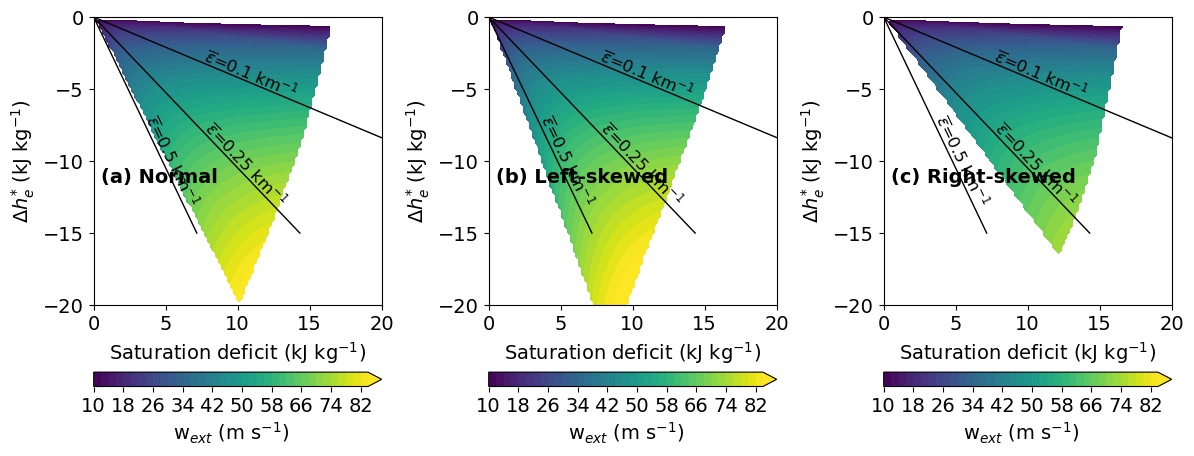

In [8]:

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_normal_wide["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_normal_wide["dh"])/1000
CAPEdist_list = np.array(df_normal_wide["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_normal_wide["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_normal_wide["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(a) Normal",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(132)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_left_wide["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_left_wide["dh"])/1000
CAPEdist_list = np.array(df_left_wide["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_left_wide["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_left_wide["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(b) Left-skewed",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(133)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_right_wide["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_right_wide["dh"])/1000
CAPEdist_list = np.array(df_right_wide["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_right_wide["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_right_wide["ent_b"])*1000
mask = (~np.isnan(sat_def_arr)) & (~np.isnan(dh_arr)) & (~np.isnan(w_arr))
Xi, Yi, Zi = scatter_to_contour(sat_def_arr[mask], dh_arr[mask], w_arr[mask])
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(c) Right-skewed",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')
plt.tight_layout()

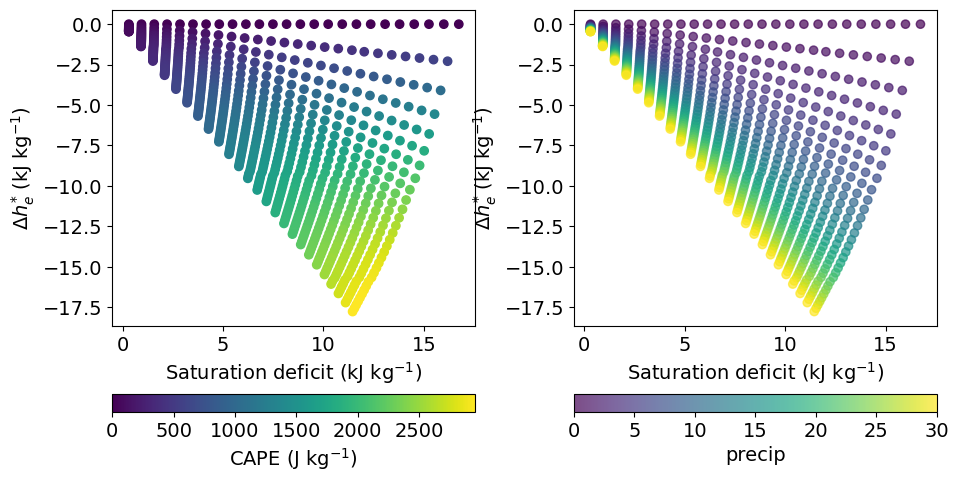

In [10]:
sat_def_arr = np.array(df_right["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_right["dh"])/1000
CAPEdist_list = np.array(df_right["CAPE_ext"])
fig = plt.figure(figsize=(14,5))
ax1 = fig.add_subplot(131)
plt.scatter(sat_def_arr, dh_arr, c=CAPEdist_list)
plt.colorbar(label="CAPE (J kg$^{-1}$)",orientation="horizontal")

ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
# ax1.set_xlim(0,20)
# ax1.set_ylim(-20,0)

ax2 = fig.add_subplot(132)
P = df_right["P"]
plt.scatter(sat_def_arr, dh_arr, c=P,alpha=0.7)
plt.colorbar(label="precip",orientation="horizontal")
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
# ax2.set_xlim(0,15)
# ax2.set_ylim(-15,0)

plt.tight_layout()

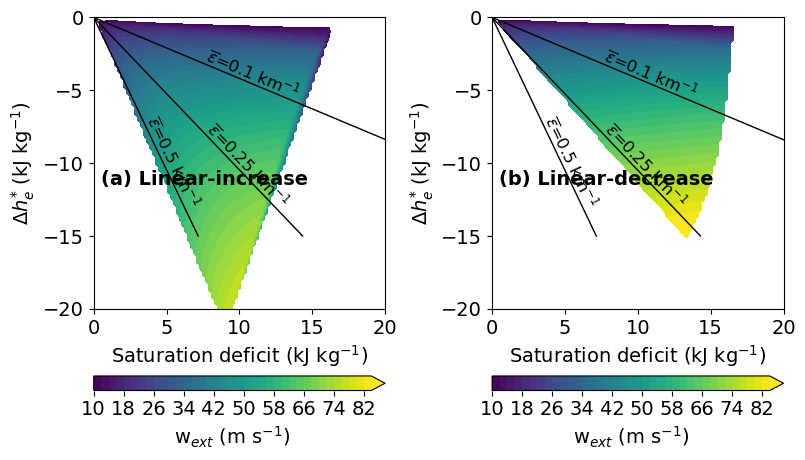

In [11]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_inc["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_inc["dh"])/1000
CAPEdist_list = np.array(df_inc["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_inc["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_inc["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(a) Linear-increase",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(132)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_dec["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_dec["dh"])/1000
CAPEdist_list = np.array(df_dec["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_dec["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_dec["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(10,85,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(b) Linear-decrease",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')
plt.tight_layout()

In [29]:
def get_Zi(df):
    sat_def_arr = np.array(df["sat_def"])*const.Lv0/1000
    dh_arr = np.array(df["dh"])/1000

    dz_arr = np.array(df["dz"])/1000
    dz = np.nanmean(dz_arr)
    ent_b_arr = np.array(df["ent_b"])*1000
    ## normal
    CAPEdist = np.array(df["CAPE_ext"])
    w_arr = np.sqrt(2*CAPEdist)
    # std_arr = np.array(df["ent_std"])
    mask = (~np.isnan(sat_def_arr)) & (~np.isnan(dh_arr)) & (~np.isnan(w_arr))
    Xi, Yi, Zi = scatter_to_contour(sat_def_arr[mask], dh_arr[mask], w_arr[mask])
    return Zi

In [30]:
# Zi_uni = get_Zi(df_uni)
Zi_normal_narrow = get_Zi(df_normal_narrow)
Zi_left_narrow = get_Zi(df_left_narrow)
Zi_right_narrow = get_Zi(df_right_narrow)

Zi_normal_wide = get_Zi(df_normal_wide)
Zi_left_wide = get_Zi(df_left_wide)
Zi_right_wide = get_Zi(df_right_wide)


Zi_normal = get_Zi(df_normal)
Zi_left = get_Zi(df_left)
Zi_right = get_Zi(df_right)

/var/folders/mk/8cspl43d4k981r_vzfv1w594k91l6t/T/ipykernel_95966/3733582154.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label = r"normal-wide $\Delta w_{ext}$", extend="both",orientation="horizontal")
/var/folders/mk/8cspl43d4k981r_vzfv1w594k91l6t/T/ipykernel_95966/3733582154.py:41: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label = r"left-wide $\Delta w_{ext}$", extend="both",orientation="horizontal")
/var/folders/mk/8cspl43d4k981r_vzfv1w594k91l6t/T/ipykernel_95966/3733582154.py:78: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior no

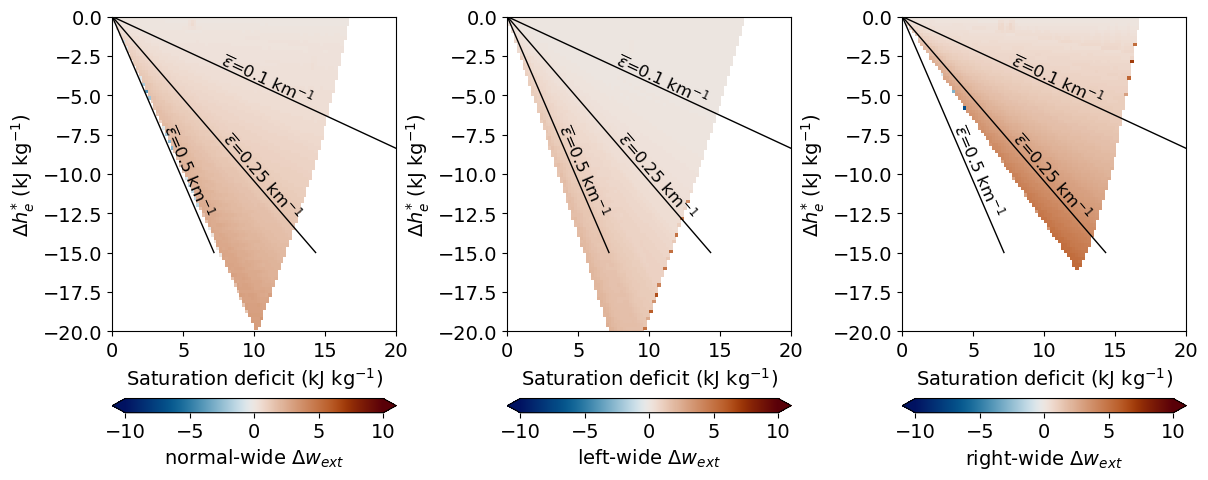

In [33]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
plt.pcolor(Xi, Yi, Zi_normal-Zi_normal_wide,cmap="cmc.vik",vmin=-10,vmax=10)
plt.colorbar(label = r"normal-wide $\Delta w_{ext}$", extend="both",orientation="horizontal")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1 = fig.add_subplot(132)
plt.pcolor(Xi, Yi, Zi_left-Zi_left_wide,cmap="cmc.vik",vmin=-10,vmax=10)
plt.colorbar(label = r"left-wide $\Delta w_{ext}$", extend="both",orientation="horizontal")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")

ax1 = fig.add_subplot(133)
plt.pcolor(Xi, Yi, Zi_right-Zi_right_wide,cmap="cmc.vik",vmin=-10,vmax=10)
plt.colorbar(label = r"right-wide $\Delta w_{ext}$", extend="both",orientation="horizontal")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
plt.tight_layout()

/var/folders/mk/8cspl43d4k981r_vzfv1w594k91l6t/T/ipykernel_95966/278615054.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label = r"normal-narrow $\Delta w_{ext}$", extend="both",orientation="horizontal")
/var/folders/mk/8cspl43d4k981r_vzfv1w594k91l6t/T/ipykernel_95966/278615054.py:41: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label = r"left-narrow $\Delta w_{ext}$", extend="both",orientation="horizontal")
/var/folders/mk/8cspl43d4k981r_vzfv1w594k91l6t/T/ipykernel_95966/278615054.py:78: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior n

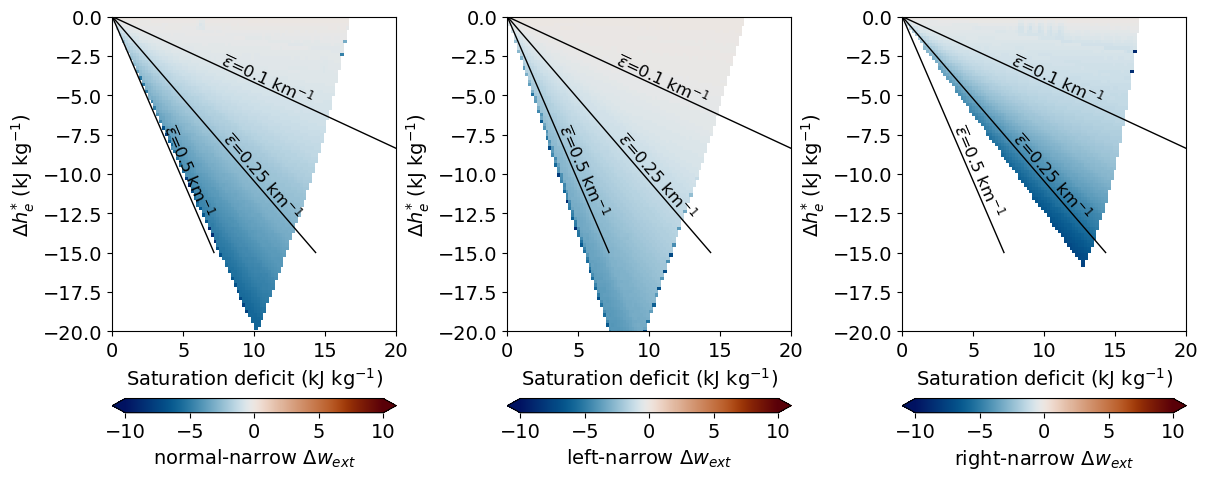

In [35]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
plt.pcolor(Xi, Yi, Zi_normal-Zi_normal_narrow,cmap="cmc.vik",vmin=-10,vmax=10)
plt.colorbar(label = r"normal-narrow $\Delta w_{ext}$", extend="both",orientation="horizontal")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1 = fig.add_subplot(132)
plt.pcolor(Xi, Yi, Zi_left-Zi_left_narrow,cmap="cmc.vik",vmin=-10,vmax=10)
plt.colorbar(label = r"left-narrow $\Delta w_{ext}$", extend="both",orientation="horizontal")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")

ax1 = fig.add_subplot(133)
plt.pcolor(Xi, Yi, Zi_right-Zi_right_narrow,cmap="cmc.vik",vmin=-10,vmax=10)
plt.colorbar(label = r"right-narrow $\Delta w_{ext}$", extend="both",orientation="horizontal")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
plt.tight_layout()

In [ ]:
## low
# CAPEdist_low = np.array(df_low["CAPE_ext"])
# w_arr_low = np.sqrt(2*CAPEdist_low)

## high


# w_arr = (w_arr_normal + w_arr_left + w_arr_right)/3

weight_left   = 1
weight_normal = 4
weight_right  = 0



weights = np.array([ weight_left, weight_normal, weight_right]) # , weight_low


Zi_stack = np.stack([Zi_left, Zi_normal, Zi_right])
w = np.asarray(weights)[:, None, None]

valid = ~np.isnan(Zi_stack)

Zi_arr = np.nansum(Zi_stack * w, axis=0) / np.sum(w * valid, axis=0)

# w_arr = (
#     weight_normal * w_arr_normal
#     + weight_left * w_arr_left
#     + weight_right * w_arr_right
# )

# Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi_arr, levels=np.arange(0,65,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-15,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,20)
ax1.set_ylim(-20,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
# ax1.text(0.5,-11.5,f"{weight_normal}; {weight_left}; {weight_right}",fontweight="bold",fontsize=14)
ax1.set_title(f"left: {weight_left};norm: {weight_normal}; right: {weight_right}",fontsize=10)
ax1.set_aspect('equal')

## plot distribution

In [24]:
def distribution_profile(nbins=50, skew="right"):
    '''
    Generate a distribution of plumes with different entrainment rates.
    
    '''
    x = np.linspace(0, 1, nbins)

    # Gamma parameters chosen to give a similar low-x peak
    shape = 4
    scale = 0.05

    # standard deviation for the central normal case
    sigma = np.sqrt(shape) * scale

    slope = 1
    intercept = 0.5
    
    if skew == "right":
        pdf = gamma.pdf(x, a=shape, scale=scale)
        Afac=0.0325
    elif skew == "normal":
        mu = 0.5
        pdf = norm.pdf(x, loc=mu, scale=sigma)
        Afac=0.0325
    elif skew == "left":
        # mirror the right-skewed gamma around x = 0.5
        pdf = gamma.pdf(1 - x, a=shape, scale=scale)
        Afac=0.0325
    elif skew == "strong-low-entrain":
        # exponential-like: maximum at x = 0
        shape_low = 1
        scale_low = 0.1
        pdf = gamma.pdf(x, a=shape_low, scale=scale_low)
        Afac=0.0325
    elif skew == "strong-high-entrain":
        # mirrored exponential-like distribution
        shape_high = 1
        scale_high = 0.1
        pdf = gamma.pdf(1 - x, a=shape_high, scale=scale_high)
        Afac=0.0325
    else:
        raise ValueError(
            f"Input: {skew} is not a valid option. "
            "Choose from 'right', 'normal', 'left', "
            "'strong-low-entrain', or 'strong-high-entrain'."
        )
    
    return x, pdf, Afac

In [25]:

def get_mass_pdf(P, z_b, skew_type="normal",const=const):
    x, gamma_pdf, Afac = distribution_profile(nbins=200, skew=skew_type)

    ## This is just an amplitude to control the peak.
    amp = z_b/Afac

    max_pdf_norm = np.max(gamma_pdf)

    ent_max = max_pdf_norm * (P/const.P0 / amp)
    ## We then get to know how far the entrainment rate extends 
    ent_spec = x * ent_max

    ## And we have the distribution of cloud base mass flux
    mb_spec = amp * gamma_pdf / max_pdf_norm
    arr_min = np.min(mb_spec)
    arr_max = np.max(mb_spec)

    # Apply the normalization formula
    mb_norm = (mb_spec - arr_min) / (arr_max - arr_min)
    return ent_spec*1000, mb_spec

def get_linear(P, z_b,skew_type="linear-increase",nbins=200,const=const):
    b = z_b*5

    a = 9.5e6
    ent_b = (-b +np.sqrt(b**2+2*a*(P/const.P0)) )/a
    ent_spec = np.linspace(0, ent_b, nbins)
    if skew_type == "linear-increase":
        mb_spec = a*ent_spec+b
    elif skew_type == "linear-decrease":
        mb_spec = -a*ent_spec+10*b
        
    
    return ent_spec*1000, mb_spec

([], [])

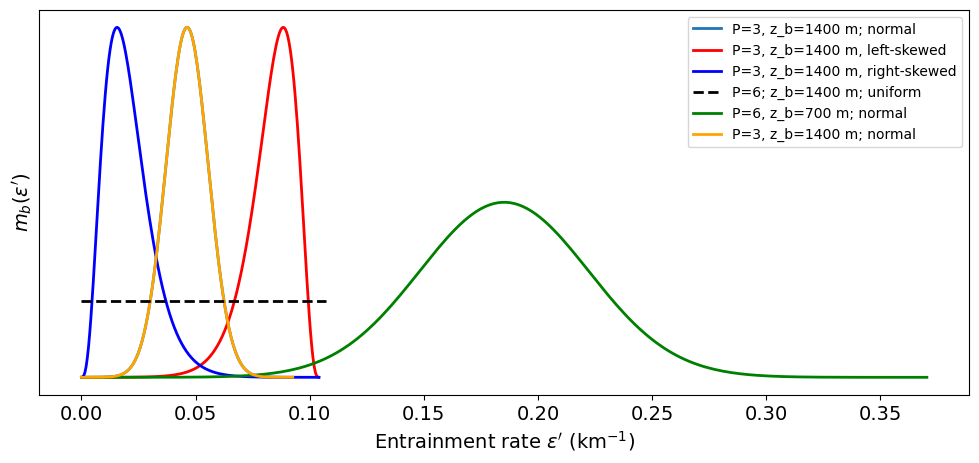

In [26]:
plt.figure(figsize=(12,5))
P=3
z_b=1400
plt.plot(*get_mass_pdf(P, z_b, skew_type="normal"), label=f"P={P}, z_b={z_b} m; normal")

plt.plot(*get_mass_pdf(P, z_b, skew_type="left"), color="r", label=f"P={P}, z_b={z_b} m, left-skewed")
plt.plot(*get_mass_pdf(P, z_b, skew_type="right"), color="b", label=f"P={P}, z_b={z_b} m, right-skewed")
# plt.plot(*get_linear(P, z_b,skew_type="linear-decrease"), "r.-", label=f"P={P}, z_b={z_b} m, linear-decrease",zorder=10)
plt.hlines(y=z_b/0.15, xmin=0, xmax=0.15/z_b * (P/const.P0)*1000, color="k", linestyle="--", label=f"P=6; z_b={z_b} m; uniform",zorder=5)
# plt.plot(*get_linear(P, z_b), "r--", label=f"P={P}, z_b={z_b} m, linear-increase",linewidth=3,zorder=10)

P=6
z_b=700
plt.plot(*get_mass_pdf(P, z_b, skew_type="normal"), label=f"P={P}, z_b={z_b} m; normal",color="green")
# plt.plot(*get_linear(P, z_b), "b.-", label=f"P={P}, z_b={z_b} m, linear-increase")
# plt.plot(*get_linear(P, z_b,skew_type="linear-decrease"), "b.-", label=f"P={P}, z_b={z_b} m, linear-decrease")
# plt.plot(np.linspace(0,emax), -700*np.linspace(0,emax)+5*700+700*emax,"k--")
P=3
z_b=1400
plt.plot(*get_mass_pdf(P, z_b, skew_type="normal"), label=f"P={P}, z_b={z_b} m; normal",color="orange")
# plt.plot(*get_linear(P, z_b), ".-", label=f"P={P}, z_b={z_b} m, linear-increase",color="orange")
plt.legend(fontsize=10)
plt.xlabel(r"Entrainment rate $\epsilon'$ (km$^{-1}$)")
plt.ylabel(r"$m_b(\epsilon')$")
# plt.ylim(2000, 12000)
plt.yticks([])
# For the same total cloud-base mass flux, a deeper boundary layer concentrates that mass flux into a narrower range of lower entrainment rates. 

## vertical profile of entrainment

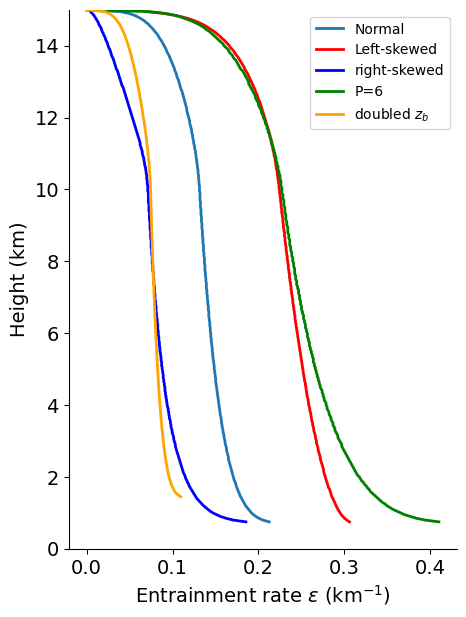

In [32]:
fig = plt.figure(figsize=(5,7))
ax1 = fig.add_subplot(111)
P=3
z_b = 700

df_normal_v = spectral_plume_skew(P=P, z_lcl = z_b, nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="normal")[0]
plt.plot(df_normal_v["ent"][df_normal_v["z"]>z_b]*1000,df_normal_v["z"][df_normal_v["z"]>z_b]/1000,label="Normal")

df_left_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="left")[0]
plt.plot(df_left_v["ent"][df_left_v["ent"]>0]*1000,df_left_v["z"][df_left_v["ent"]>0]/1000,label="Left-skewed",color="r")

# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]
# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="P=3; linear-increase",color="r",linestyle="--")

# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-decrease")[0]
# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="linear-decrease",color="b",linestyle="--")


df_right_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="right")[0]
plt.plot(df_right_v["ent"][df_right_v["ent"]>0]*1000,df_right_v["z"][df_right_v["ent"]>0]/1000,label="right-skewed",color="b")

P = 6
z_b = 700

df_normal_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="normal")[0]
plt.plot(df_normal_v["ent"][df_normal_v["z"]>z_b]*1000,df_normal_v["z"][df_normal_v["z"]>z_b]/1000,label=f"P=6", color="green")
# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]

# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="P=6; linear-increase",color="b",linestyle="--")
# plt.plot(df_increase_v["ent_uniform"][df_increase_v["ent_uniform"]>0]*1000,df_increase_v["z"][df_increase_v["ent_uniform"]>0]/1000,label="P=6; uniform",color="k",linestyle="-")


P = 3
z_b = 1400

df_normal_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="normal")[0]
plt.plot(df_normal_v["ent"][df_normal_v["z"]>z_b]*1000,df_normal_v["z"][df_normal_v["z"]>z_b]/1000,label=r"doubled $z_b$", color="orange")
# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]
# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label=r"Doubled $z_b$; linear-increase ",color="orange",linestyle="--")

plt.legend(loc="upper right",fontsize=10)
ax1.set_xlabel(r"Entrainment rate $\epsilon$ (km$^{-1}$)")
ax1.set_ylabel("Height (km)")
plt.ylim(0,15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

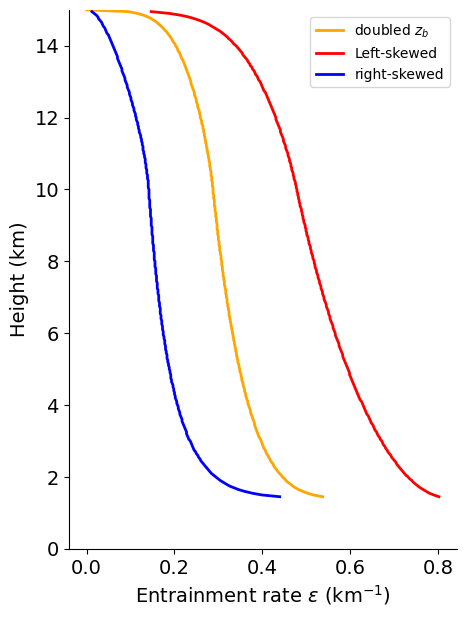

In [28]:
fig = plt.figure(figsize=(5,7))
ax1 = fig.add_subplot(111)
# P=3
# z_b = 700

# df_normal_v = spectral_plume_skew(P=P, z_lcl = z_b, nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="normal")[0]
# plt.plot(df_normal_v["ent"][df_normal_v["z"]>z_b]*1000,df_normal_v["z"][df_normal_v["z"]>z_b]/1000,label="Normal")

# df_left_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="left")[0]
# plt.plot(df_left_v["ent"][df_left_v["ent"]>0]*1000,df_left_v["z"][df_left_v["ent"]>0]/1000,label="Left-skewed",color="r")

# # df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]
# # plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="P=3; linear-increase",color="r",linestyle="--")

# # df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-decrease")[0]
# # plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="linear-decrease",color="b",linestyle="--")


# df_right_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="right")[0]
# plt.plot(df_right_v["ent"][df_right_v["ent"]>0]*1000,df_right_v["z"][df_right_v["ent"]>0]/1000,label="right-skewed",color="b")

# P = 6
# z_b = 700

# df_normal_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="normal")[0]
# plt.plot(df_normal_v["ent"][df_normal_v["z"]>z_b]*1000,df_normal_v["z"][df_normal_v["z"]>z_b]/1000,label=f"P=6", color="green")
# # df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]

# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="P=6; linear-increase",color="b",linestyle="--")
# plt.plot(df_increase_v["ent_uniform"][df_increase_v["ent_uniform"]>0]*1000,df_increase_v["z"][df_increase_v["ent_uniform"]>0]/1000,label="P=6; uniform",color="k",linestyle="-")


P = 16
z_b = 1400

df_normal_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="normal")[0]
plt.plot(df_normal_v["ent"][df_normal_v["z"]>z_b]*1000,df_normal_v["z"][df_normal_v["z"]>z_b]/1000,label=r"doubled $z_b$", color="orange")
# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]
# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label=r"Doubled $z_b$; linear-increase ",color="orange",linestyle="--")
df_left_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="left")[0]
plt.plot(df_left_v["ent"][df_left_v["ent"]>0]*1000,df_left_v["z"][df_left_v["ent"]>0]/1000,label="Left-skewed",color="r")

# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]
# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="P=3; linear-increase",color="r",linestyle="--")

# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-decrease")[0]
# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="linear-decrease",color="b",linestyle="--")


df_right_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="right")[0]
plt.plot(df_right_v["ent"][df_right_v["ent"]>0]*1000,df_right_v["z"][df_right_v["ent"]>0]/1000,label="right-skewed",color="b")
plt.legend(loc="upper right",fontsize=10)
ax1.set_xlabel(r"Entrainment rate $\epsilon$ (km$^{-1}$)")
ax1.set_ylabel("Height (km)")
plt.ylim(0,15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

## Craig and Cohen

In [88]:
from scipy.optimize import curve_fit
from scipy.stats import norm

# Define the CDF function you want to fit (e.g., Normal distribution)
def normal_cdf(x, mean, std_dev):
    return norm.cdf(x, loc=mean, scale=std_dev)

def cdf_fit(x, y, mode = "shallow"):
    
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    # Initial guesses from the observed quantiles
    mask = (y > 0) & (y < 1)

    z = norm.ppf(y[mask])
    sigma0, mean0 = np.polyfit(z, x[mask], 1)

    popt, pcov = curve_fit(
        normal_cdf,
        x,
        y,
        p0=[mean0, sigma0],
        bounds=([-np.inf, 1e-6], [np.inf, np.inf])
    )

    mean, std_dev = popt

    R = np.linspace(
        x.min(),
        x.max(),
        500
    )
    if mode =="deep":
        R = np.linspace(
        x.min(),
        x.max()+4*std_dev,
        500
    )

    cdf = norm.cdf(R, loc=mean, scale=std_dev)
    pdf_R = norm.pdf(R, loc=mean, scale=std_dev)
    if mode =="deep":
        R = R*1.6
    return R, cdf, pdf_R

df=pd.read_csv("./shallow_few.csv")
R_shallow, cdf_shallow,pdf_shallow_R = cdf_fit(df["ent_shallow"].values, df["m_shallow"].values)
df = pd.read_csv("./deep_shallow_dataset.csv")
R_deep, cdf_deep,pdf_deep_R = cdf_fit(df["ent_deep"].values,  df["m_deep"].values, mode="deep")



In [89]:
cdf_deep.max()

0.9999999991086119

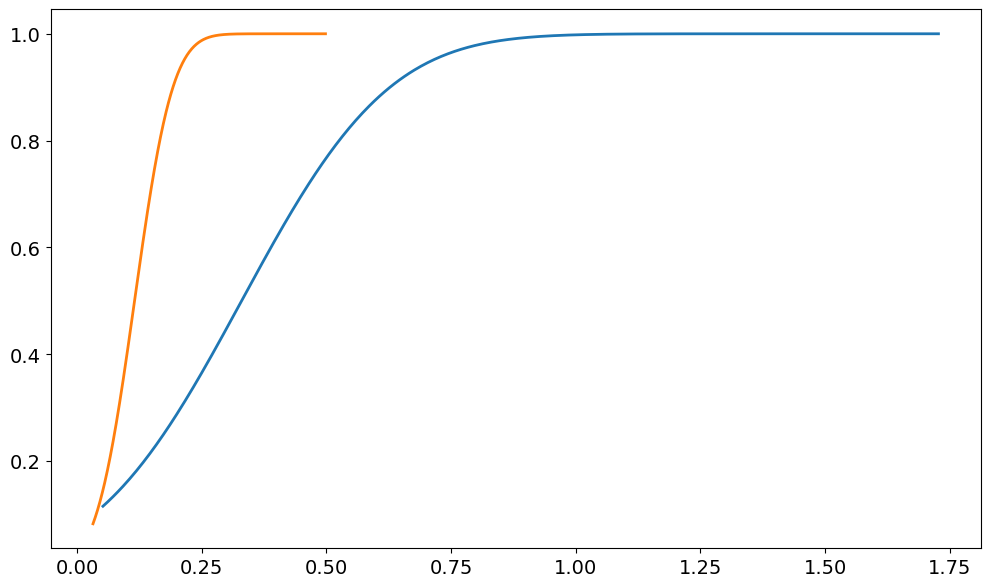

In [141]:
plt.plot(R_deep, cdf_deep)
# plt.plot(df["ent_deep"].values,  df["m_deep"].values)
plt.plot(R_shallow,cdf_shallow)

In [106]:
pdf_R_norm_shallow = pdf_shallow_R / np.trapz(pdf_shallow_R, R_shallow)
epsilon_shallow = 0.2 / R_shallow 
pdf_epsilon_shallow = pdf_R_norm_shallow * 0.2 / epsilon_shallow**2

In [127]:
pdf_R_norm_deep = pdf_deep_R / np.trapz(pdf_deep_R, R_deep)
epsilon_deep = 0.2 / R_deep 
pdf_epsilon_deep = pdf_R_norm_deep * 0.2 / epsilon_deep**2



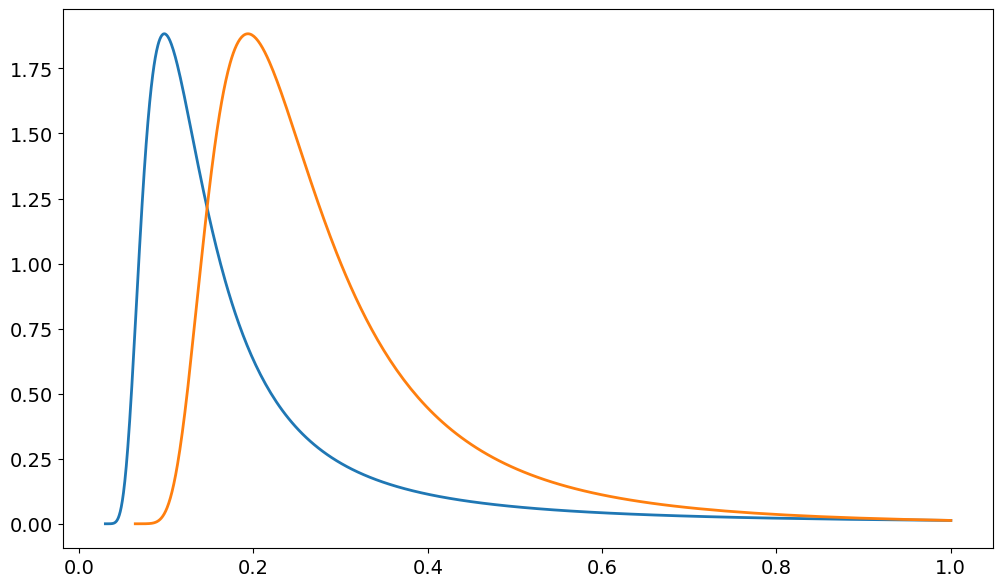

In [137]:
x_scaled = epsilon_deep/epsilon_deep.max()
y_scaled = pdf_epsilon_deep#*epsilon_deep.max()

plt.plot(x_scaled,y_scaled)

x_scaled = epsilon_shallow/epsilon_shallow.max()
y_scaled = pdf_epsilon_deep#*epsilon_shallow.max()

plt.plot(x_scaled,y_scaled)

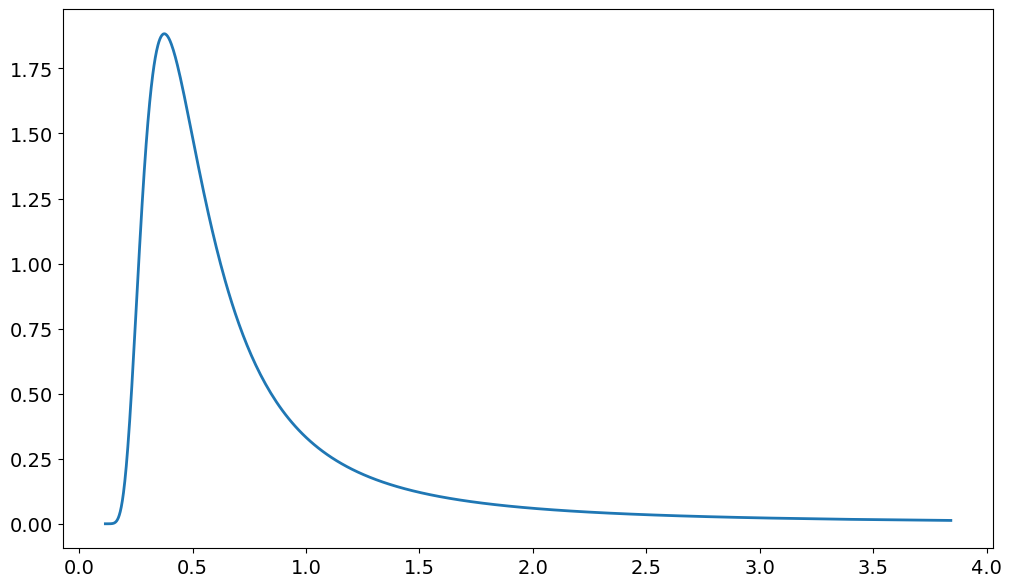

In [133]:
plt.plot( epsilon_deep,pdf_epsilon_deep)

In [139]:
np.trapz(epsilon_deep/4, pdf_epsilon_deep)

0.23768409830710202

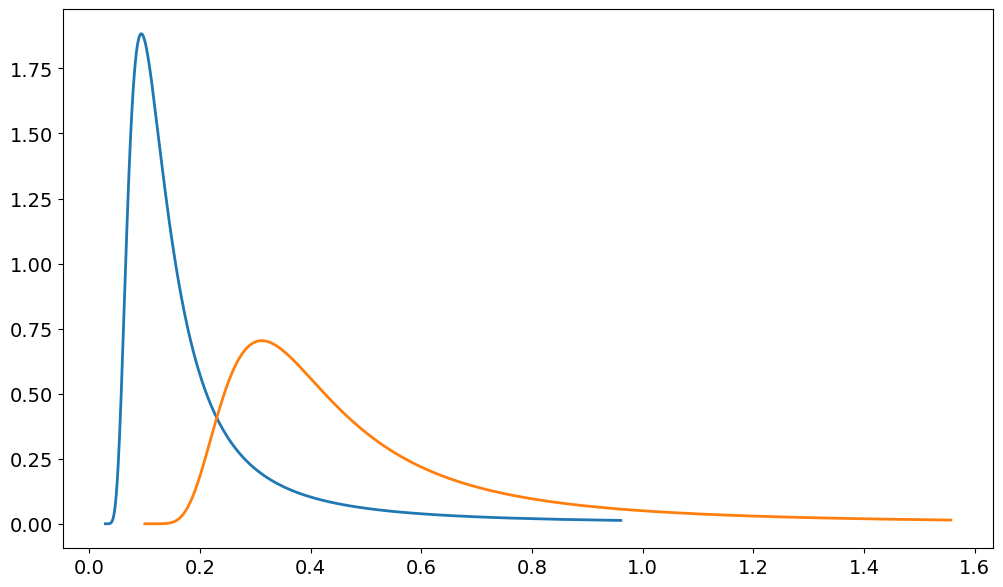

In [138]:
plt.plot(epsilon_deep/4, pdf_epsilon_deep)
plt.plot(epsilon_shallow/4, pdf_epsilon_shallow)